In [ ]:
import matplotlib.pyplot as plt
from matplotlib import patches
import numpy as np

import torch
from torchvision import datasets, transforms



##Problema de Classificação

In [ ]:
MNIST = datasets.MNIST('.', train = False, transform = transforms.ToTensor(), download = True)

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:11<00:00, 895653.34it/s] 


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 131072.71it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:06<00:00, 239470.09it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 3119968.68it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [ ]:
##Channel First: Padrao do Pytorch

dado, rotulo = MNIST[0]

print(type(dado), type(rotulo))
print(dado.size(), rotulo)

#  1 = só tem um canal de cor
# 28 = dimensão da imagem
# 28 = dimensão da imagem

<class 'torch.Tensor'> <class 'int'>
torch.Size([1, 28, 28]) 7


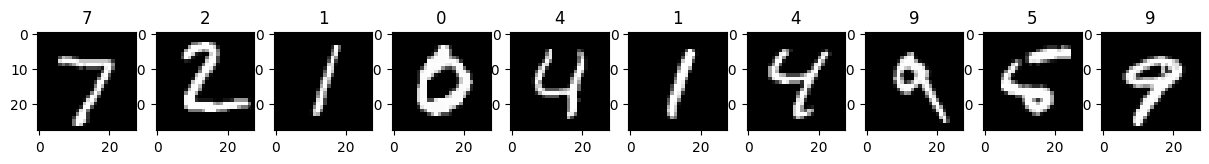

In [ ]:
fig, axs = plt.subplots(1, 10, figsize = (15,4))
for i in range(10):
  dado, rotulo = MNIST[i]
  axs[i].imshow(dado[0], cmap = 'gray')
  axs[i].set_title(rotulo)


In [ ]:
CIFAR10 = datasets.CIFAR10('./',
                            train = False,
                            transform = transforms.ToTensor(),
                            download = True)


100%|██████████| 170498071/170498071 [00:12<00:00, 13288102.59it/s]


Extracting ./cifar-10-python.tar.gz to ./


In [ ]:
dado, rotulo = CIFAR10[0]

print(type(dado), type(rotulo))
print(dado.size(), rotulo)

<class 'torch.Tensor'> <class 'int'>
torch.Size([3, 32, 32]) 3


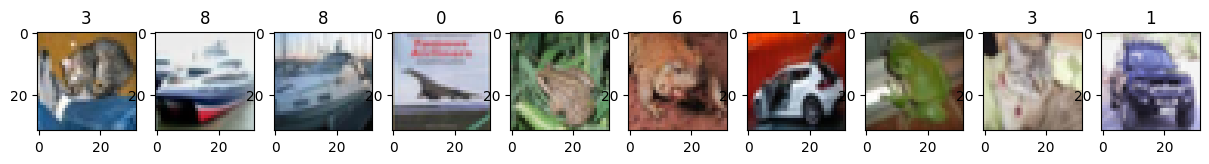

In [ ]:
fig, axs = plt.subplots(1, 10, figsize = (15,4))
for i in range(10):
  dado, rotulo = CIFAR10[i]
  #imagens são carregadas na dimensão C x H x W
  # é preciso permutar as dimensões para plot.
  axs[i].imshow(dado.permute(1,2,0))
  axs[i].set_title(rotulo)


##Problema de Detecção

In [ ]:
VOC = datasets.VOCDetection('.',
                            year = '2012',
                            transform = transforms.ToTensor(),
                            image_set = 'train',
                            download = True)

100%|██████████| 1999639040/1999639040 [01:29<00:00, 22302948.34it/s]


Extracting ./VOCtrainval_11-May-2012.tar to .


<class 'torch.Tensor'> <class 'dict'>
torch.Size([3, 442, 500])


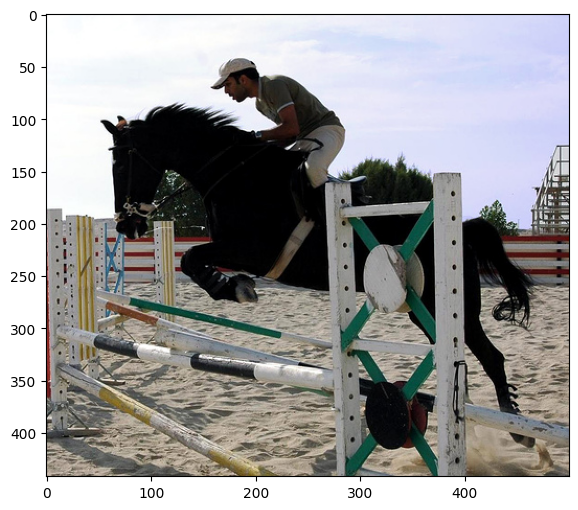

In [ ]:
dado, rotulo = VOC[0]
print(type(dado), type(rotulo))

print(dado.size())

dado = dado.permute(1,2,0)
plt.figure(figsize = (8,6))
plt.imshow(dado)


In [ ]:
rotulo

{'annotation': {'folder': 'VOC2012',
  'filename': '2008_000008.jpg',
  'source': {'database': 'The VOC2008 Database',
   'annotation': 'PASCAL VOC2008',
   'image': 'flickr'},
  'size': {'width': '500', 'height': '442', 'depth': '3'},
  'segmented': '0',
  'object': [{'name': 'horse',
    'pose': 'Left',
    'truncated': '0',
    'occluded': '1',
    'bndbox': {'xmin': '53', 'ymin': '87', 'xmax': '471', 'ymax': '420'},
    'difficult': '0'},
   {'name': 'person',
    'pose': 'Unspecified',
    'truncated': '1',
    'occluded': '0',
    'bndbox': {'xmin': '158', 'ymin': '44', 'xmax': '289', 'ymax': '167'},
    'difficult': '0'}]}}

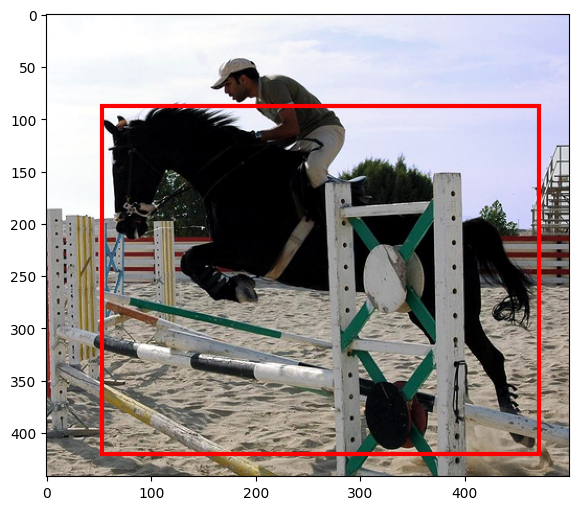

In [ ]:
bbox = rotulo['annotation']['object'][0]['bndbox']
xmax = int(bbox['xmax'])
xmin = int(bbox['xmin'])
ymax = int(bbox['ymax'])
ymin = int(bbox['ymin'])

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(dado)

w, h = xmax-xmin, ymax-ymin
rect = patches.Rectangle((xmin,ymin),w,h,linewidth=3,edgecolor='r',facecolor='none')
ax.add_patch(rect)
plt.show()

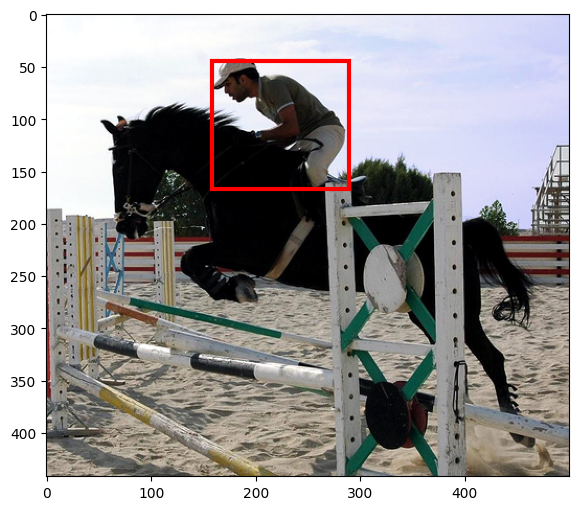

In [ ]:
bbox = rotulo['annotation']['object'][1]['bndbox']
xmax = int(bbox['xmax'])
xmin = int(bbox['xmin'])
ymax = int(bbox['ymax'])
ymin = int(bbox['ymin'])

fig, ax = plt.subplots(figsize=(8,6))
ax.imshow(dado)

w, h = xmax-xmin, ymax-ymin
rect = patches.Rectangle((xmin,ymin),w,h,linewidth=3,edgecolor='r',facecolor='none')
ax.add_patch(rect)
plt.show()

Para resolver o problema de detecção temos que contar com 4 neurônios que serão a definição do xmin, ymin, xmax, ymax

##Problema de Segmentação

Ao invés de definir um retângulo em torno da região onde está o objeto, a segmentação cobre a área do objeto pixel a pixel.

In [ ]:
VOCs = datasets.VOCSegmentation('.',
                                year = '2012',
                                image_set = 'train',
                                download = True,
                                transform = transforms.ToTensor(),
                                target_transform = transforms.ToTensor()
                               )

Using downloaded and verified file: ./VOCtrainval_11-May-2012.tar
Extracting ./VOCtrainval_11-May-2012.tar to .


In [ ]:
dado, rotulo = VOCs[0]
print(type(dado), type(rotulo))

print(dado.size(), rotulo.size())


<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([3, 281, 500]) torch.Size([1, 281, 500])


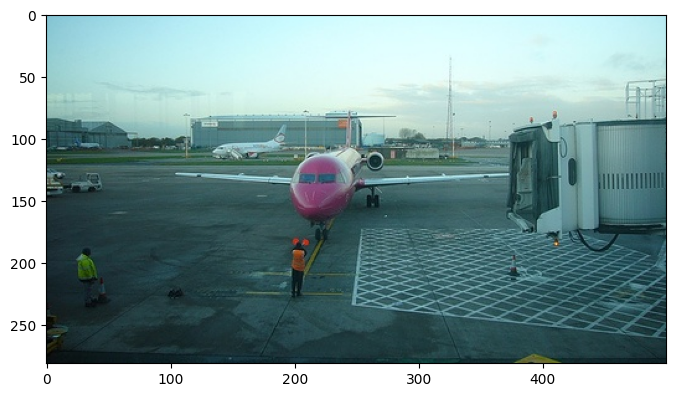

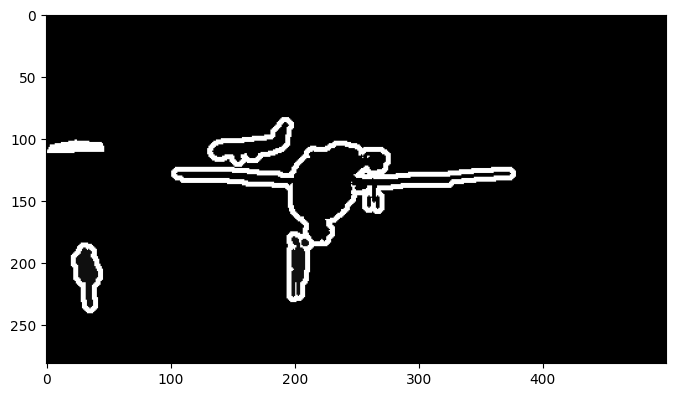

In [ ]:
dado = dado.permute(1,2,0)

plt.figure(figsize = (8,6))
plt.imshow(dado)

plt.figure(figsize = (8,6))
plt.imshow(rotulo[0], cmap = 'gray')

#Convolução

Operação entre duas funções que resultam numa terceira função.
Somatório do produto entre duas funções, sendo uma delas invertida e deslocada.

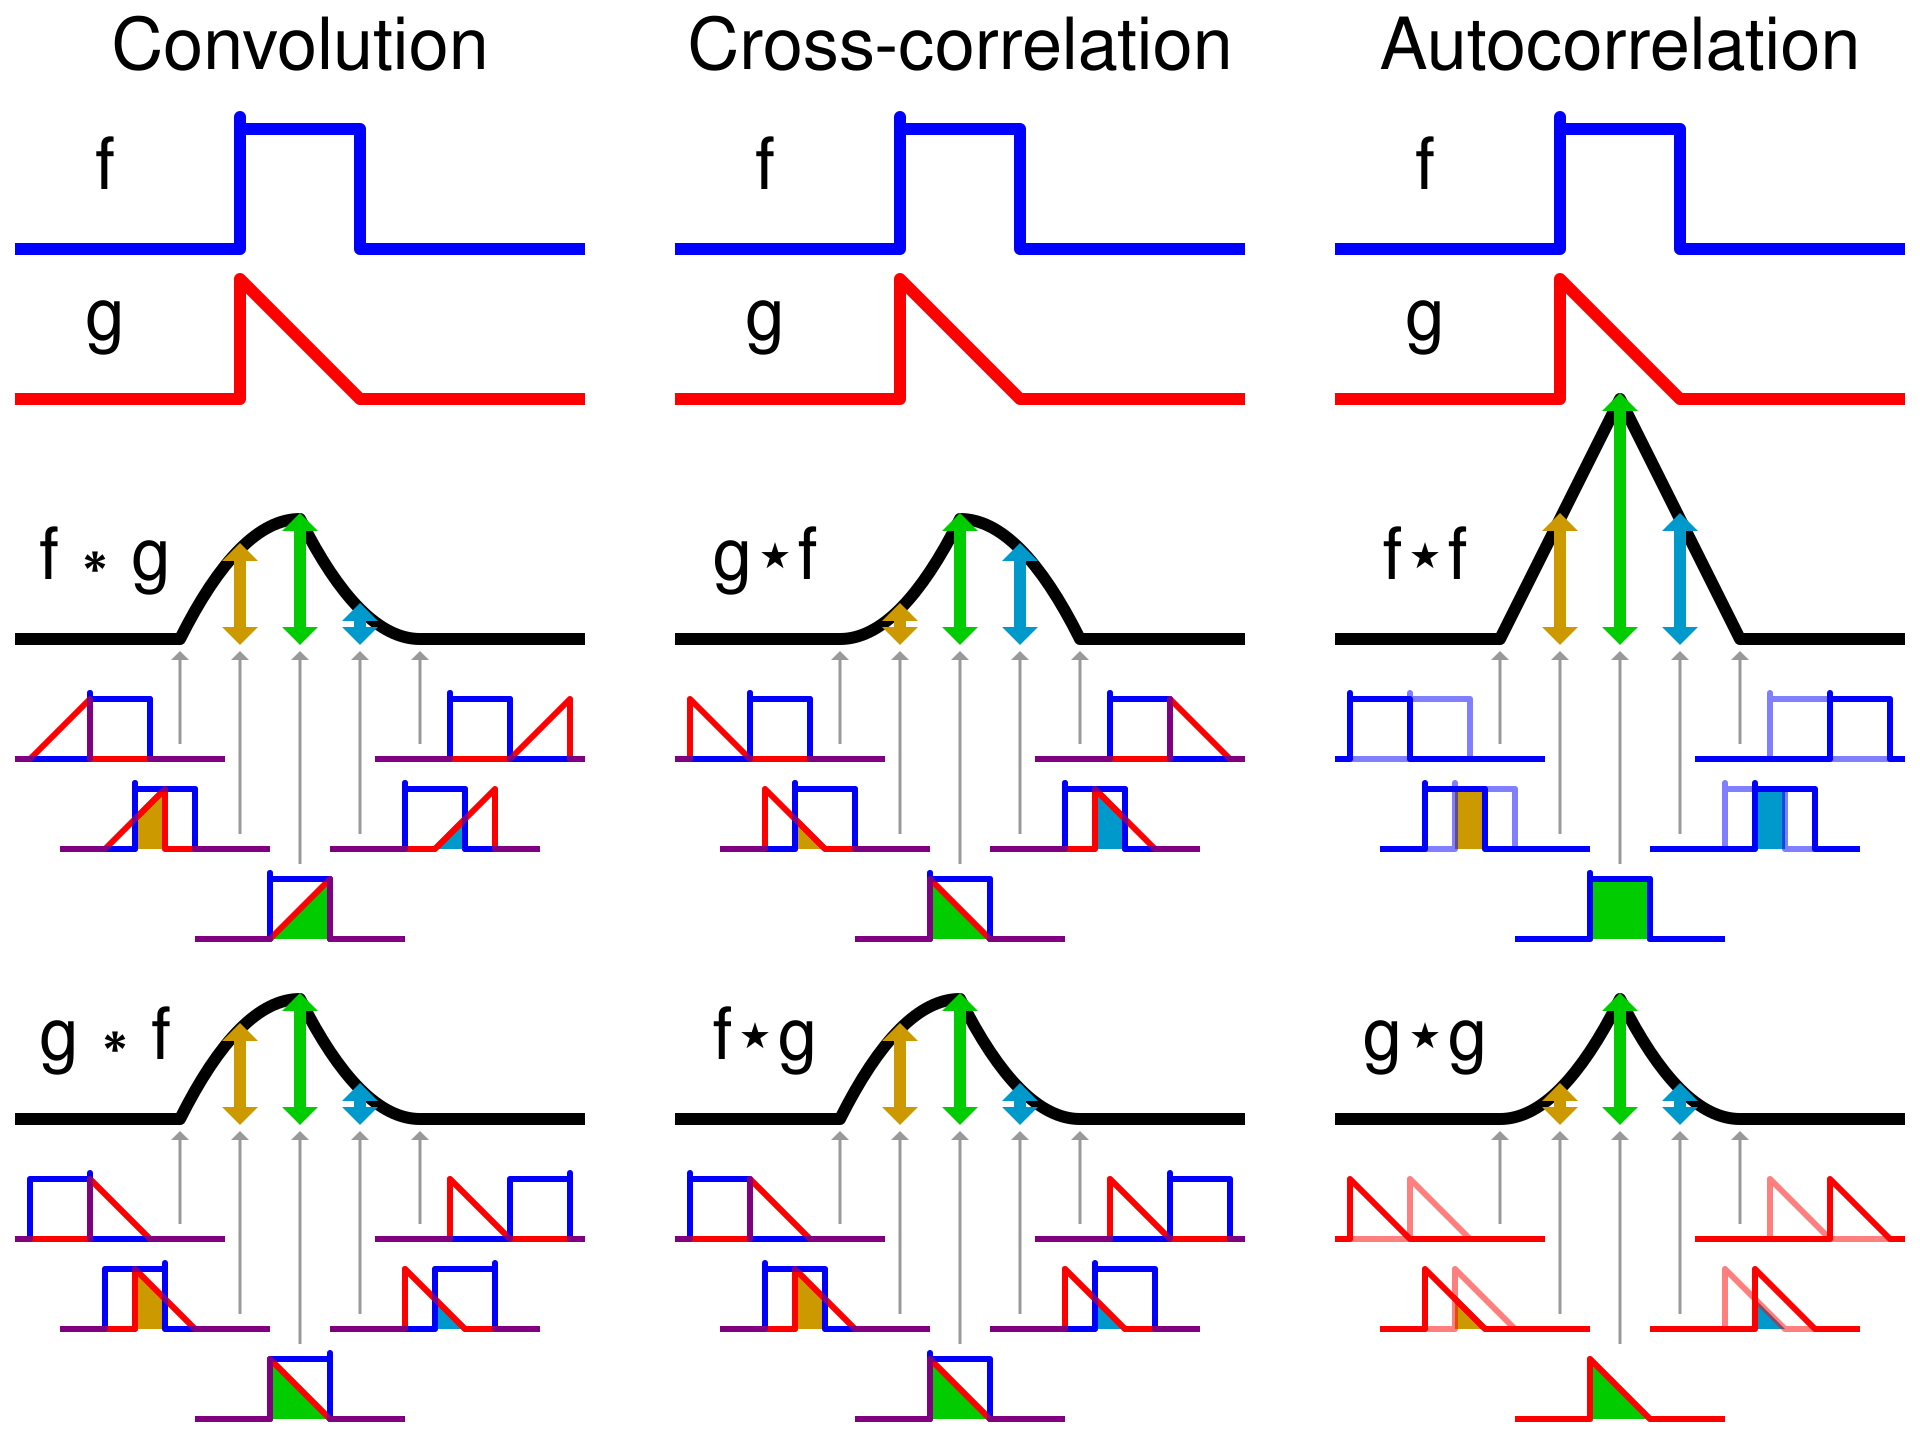

#Convolução 1D

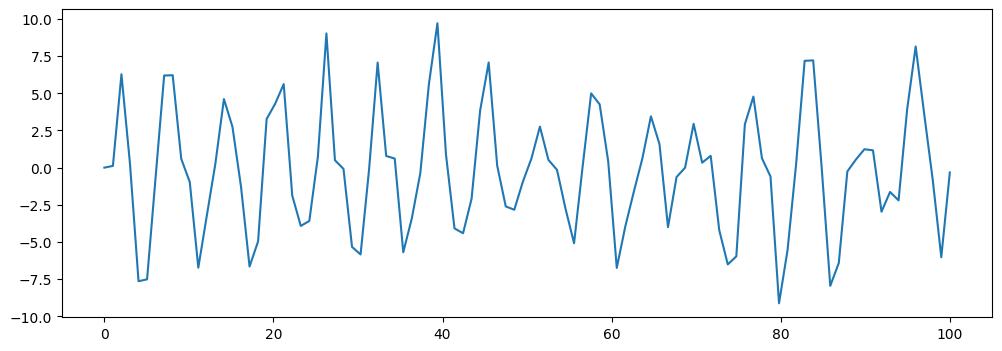

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import convolve

x = np.linspace(0, 100, 100)
y = 10 * np.sin(x) * np.random.rand(x.shape[0])

plt.figure(figsize=(12, 4))
plt.plot(x,y)

Função que usa o matplotlib para imprimir os sinais 1D como imagens

In [ ]:
def show(valores, title,):
  plt.figure(figsize=(len(valores), 2))
  plt.imshow(valores[np.newaxis, :], cmap = 'gray')
  for k, s in enumerate(valores):
    plt.text(k, 0, '{:.1f}'.format(s), fontsize = 16, color = 'red', ha='center', va='center')
  plt.title(title, fontsize = 18)
  plt.yticks([])

Representalçao 1D

Utilizamos um pequeno trecho do sinal para ilustrar (plotar) o efeito da convolução.

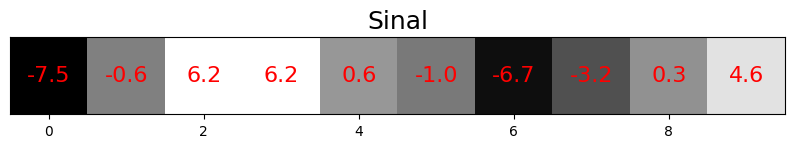

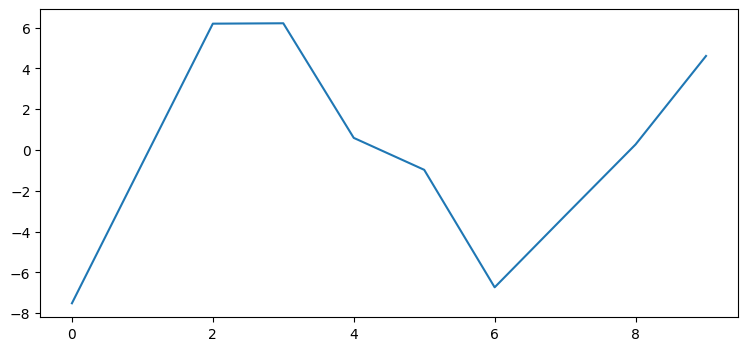

In [ ]:
sinal = y[5:15]
show(sinal, 'Sinal')

plt.figure(figsize =(9, 4))
plt.plot(sinal)

Kernel

No processamento de imagens, o kernel é um filtro convolucional. É uma matriz n-dimensional que será operada com o dado através da convolução.

Podemos dizer que a convolução mede a semelhança entre os dois sinais.

Precisamos portanto propor um kernel que simule o padrão procurado: intervalos crescentes.

>> Lembre-se: A convolução opera as funções após **inverter o kernel**.


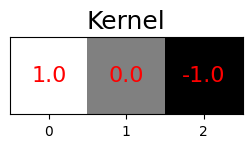

In [ ]:
kernel = np.asarray([1,0,-1])
show(kernel, 'Kernel')

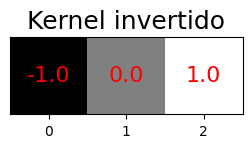

In [ ]:
#kernel invertido

kernel_invertido = np.flip(kernel)
show(kernel_invertido, 'Kernel invertido')

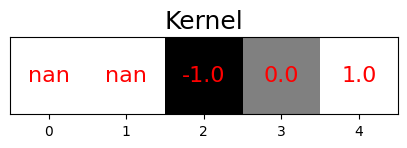

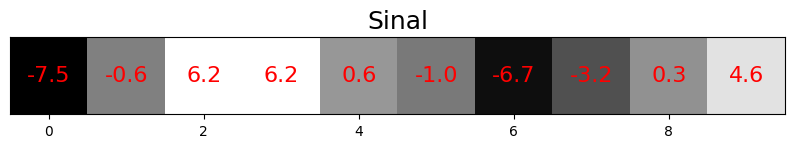

In [ ]:
#Alterando o valor de u para controlar o deslocamento

u=2
deslocamento = [float('nan')] * u
kernel_deslocado = np.hstack( (deslocamento, kernel_invertido))

show(kernel_deslocado, 'Kernel')
show(sinal, 'Sinal')

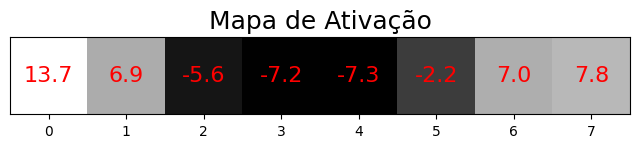

In [ ]:
ativacao = convolve(sinal, kernel, mode ='valid')
show(ativacao, 'Mapa de Ativação')

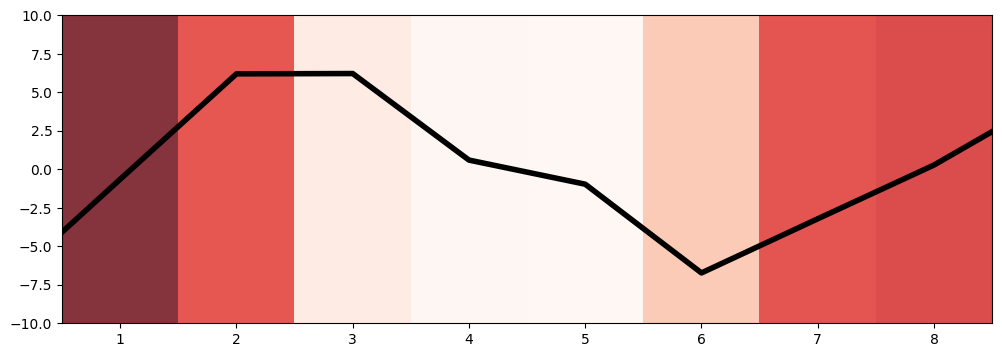

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(sinal, color = 'k', linewidth=4)
plt.imshow(ativacao[np.newaxis, :], cmap = 'Reds', aspect = 'auto', alpha = 0.8, extent = (0.5, 8.5, -10, 10))


#Convolução 2D


In [ ]:
from skimage import io, color, transform, data
from scipy.signal import convolve
import matplotlib.pyplot as plt
import numpy as np

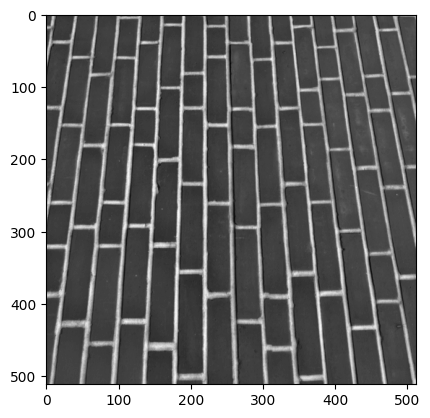

In [ ]:
img = data.brick()
plt.imshow(img, cmap = 'gray')

In [ ]:
def show(valores, title,):
  plt.figure(figsize=(len(valores), len(valores)))
  plt.imshow(valores, cmap = 'gray')

  for i, line in enumerate(valores):
    for j, col in enumerate(line):
      plt.text(j, i, '{:.1f}'.format(col), fontsize = 16, color = 'red', ha='center', va='center')
  plt.title(title, fontsize = 18)
  plt.yticks([])
  plt.xticks([])
  plt.savefig(title+'.png', format='png', dpi=100)

##Definindo dois kernels diferentes

* Kernel de bordas verticais
* Kernel de bordas horizontais

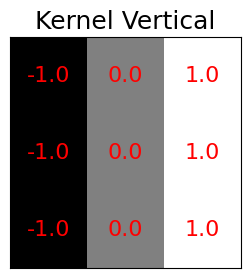

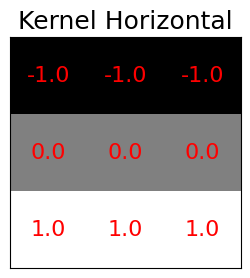

In [ ]:
kernel_vertical = np.asarray([[-1, 0, 1],
                              [-1, 0, 1],
                              [-1, 0, 1]])

show(kernel_vertical, 'Kernel Vertical')

kernel_horizontal = np.asarray([[-1, -1, -1],
                                [0, 0, 0],
                                [1, 1, 1]])

show(kernel_horizontal, 'Kernel Horizontal')

##Fazendo a convolução de ambos os kernels com a imagem de tijolos. Cada kernel destacará partes diferentes da imagem.

###O resultado da ativação entre o dado do kernel é chamado de **MAPA DE CARACTERÍSTICAS** ou **MAPA DE ATIVAÇÃO**

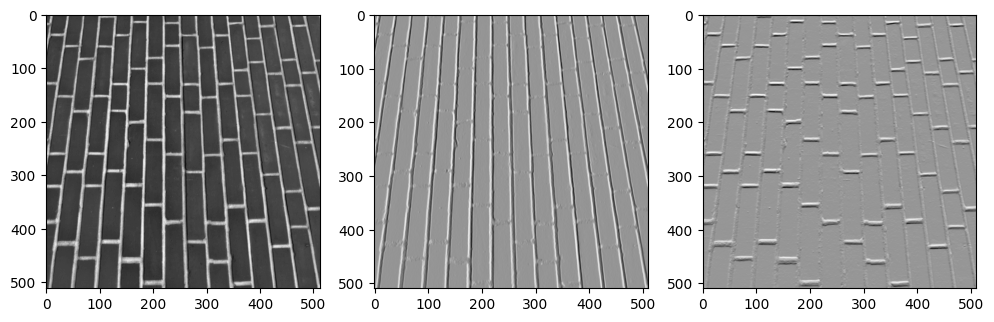

In [ ]:
mapa_caracteristica_vertical = convolve(img, kernel_vertical, mode = 'valid')
mapa_caracteristica_horizontal = convolve(img, kernel_horizontal, mode = 'valid')


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap = 'gray')

plt.subplot(1, 3, 2)
plt.imshow(mapa_caracteristica_vertical, cmap='Greys')

plt.subplot(1, 3, 3)
plt.imshow(mapa_caracteristica_horizontal, cmap='Greys')

#Filtros Convolucionais

Kernels são filtros convolucionais.
Os pesos do kernel carregam o padrão que será procurado no dado original

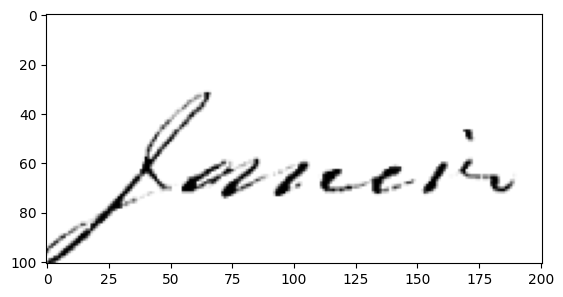

In [ ]:
img_original = io.imread('Freire_Alemao_1416281_001.png')
img = img_original[:,:,0]
plt.imshow(img, cmap='gray')

#**Filtro da Média**

Aplicar esse filtro, resultará em uma suavização da imagem original, mais 'borrada', menos nítida.

Tira a média dos pixels de subregiões da imagem.

In [ ]:
def show(img, kernel, resultado, titulo):
  fig, axs = plt.subplots(1, 3, figsize=(15, 5))
  plot = [img, kernel, resultado]
  titulos = ['Imagem Original', 'Filtro', 'Mapa de Ativação']
  for k, ax in enumerate(axs):
    ax.imshow(plot[k], cmap='gray')
    ax.set_title(titulos[k])
    ax.set_xticks([])
    ax.set_yticks([])

  for i, line in enumerate(kernel):
    for j, col in enumerate(line):
      axs[1].text(j, i, '{:.2f}'.format(col), fontsize = 16, color = 'red', ha='center', va='center')

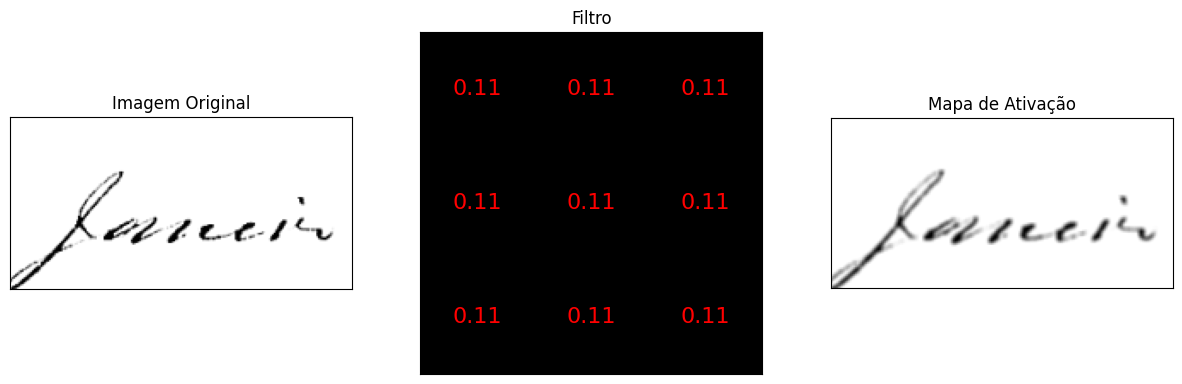

In [ ]:
kernel_media = np.zeros((3,3))
kernel_media[:] = 1.0/(3**2)

resultado = convolve(img, kernel_media, mode = 'valid')
show(img, kernel_media, resultado, titulo)

#**Sobel**

Se parece com o filtro anterior de bordas, com a diferença que os vizinhos diretos do pixel central tem valor absoluto de maior intensidade (na horizontal ou na vertical).

Após a convolução, podemos imprimir os valores absolutos para visualizar as bordas independente do sinal da ativação.

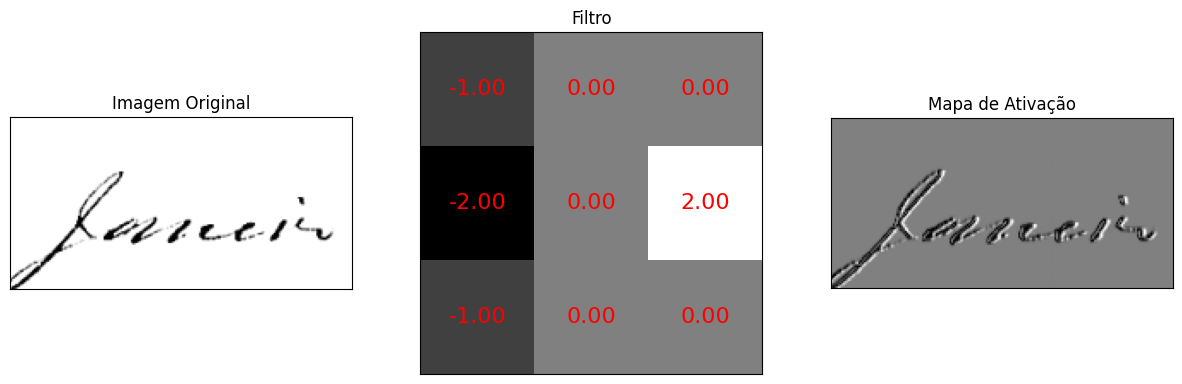

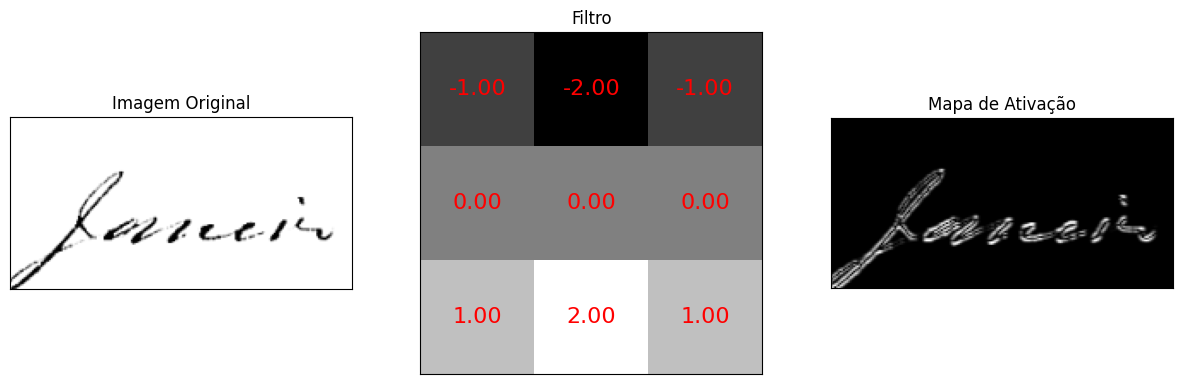

In [ ]:
#Sobel Vertical

sobel_vertical = np.zeros((3,3))
sobel_vertical[:, 0] = -1
sobel_vertical[:, 2] = 0
sobel_vertical[1, [0, 2]] = [-2, 2]

resultado = convolve(img, sobel_vertical, mode = 'valid')
show(img, sobel_vertical, np.abs(resultado), titulo)

#Sobel Horizontal

sobel_horizontal = np.zeros((3,3))
sobel_horizontal[0, :] = -1
sobel_horizontal[2, :] = 1
sobel_horizontal[[0, 2], 1] = [-2, 2]

resultado = convolve(img, sobel_horizontal, mode = 'valid')
show(img, sobel_horizontal, np.abs(resultado), titulo)

#**Laplace**

Filtro para detecção de bordas. Diferente do sobel, este filtro destaca igualmente bordas de diferentes direções.


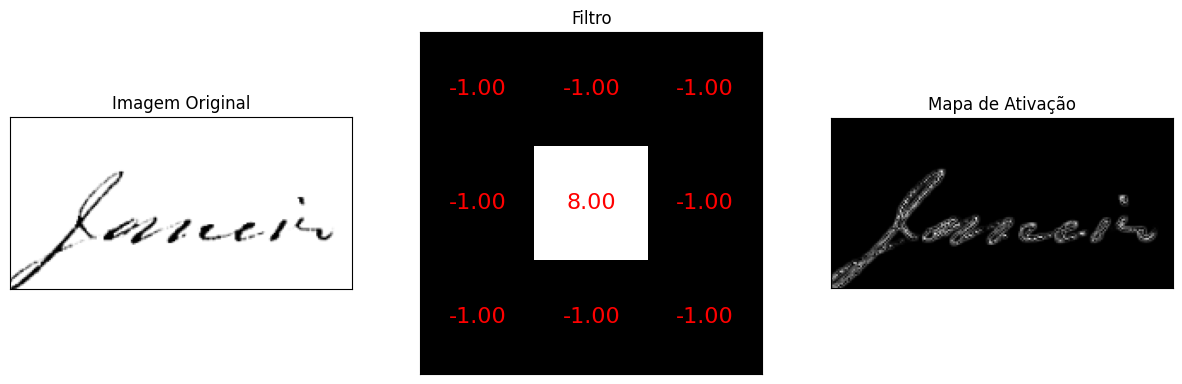

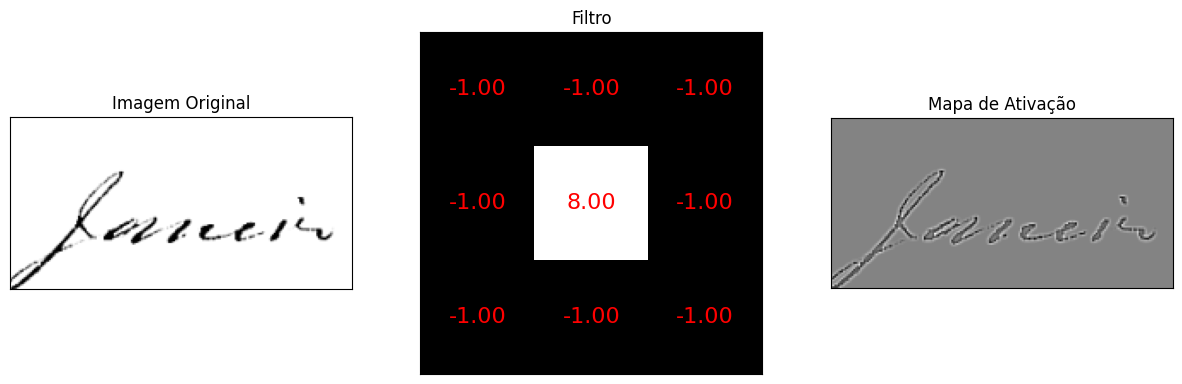

In [ ]:
laplace = np.ones((3,3)) * -1
laplace[1, 1] = 8

resultado = convolve(img, laplace, mode = 'valid')
show(img, laplace, np.abs(resultado), titulo)

resultado = convolve(img, laplace, mode = 'valid')
show(img, laplace, resultado, titulo) #sem o valor absoluto

#**Convolução e Padrões Complexos**

NameError: name 'patches' is not defined

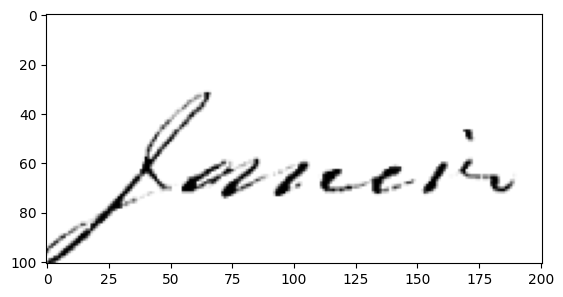

In [ ]:
img_original = io.imread('Freire_Alemao_1416281_001.png')
img = img_original[:, :, 0]
retangulo = [50, 170, 100, 100]

fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
ax.add_patch(patches.Rectangle((retangulo[2], retangulo[0]), (retangulo[3]- retangulo[2]), (retangulo[1] - retangulo[0]), color='red', fill=False))